In [1]:
import pandas as pd
import numpy as np

path = r"C:\Users\Highlightning\Documents\Ciencia de Datos\Proyectos\Churn Predictor and LTV\data\raw\random_raw_customer_data.csv"

df_raw = pd.read_csv(path)
n_rows, n_cols = df_raw.shape
print(f"Number of rows: {n_rows:,} | Number of columns: {n_cols:,}\n")

report = []
for col in df_raw.columns:
    report.append({
        "col":      col,
        "len":      df_raw[col].count(),
        "dtype":    df_raw[col].dtypes,
        "NaN":      df_raw[col].isnull().sum(),
        "0":        df_raw[col].eq(0).sum(),
        "'0'":      df_raw[col].eq('0').sum(),
        "Unique":   df_raw[col].unique()[0:7].tolist(),
        "N_unique": df_raw[col].nunique()
    })
df_report = pd.DataFrame(report)
pd.set_option("display.max_colwidth", None)
df_report

Number of rows: 2,500 | Number of columns: 11



,col,len,dtype,NaN,0,'0',Unique,N_unique
0,CustomerID,2500,str,0,0,0,"[CUST-1000, CUST-1001, CUST-1002, CUST-1003, CUST-1004, CUST-1005, CUST-1006]",2500
1,TenureMonths,2500,int64,0,0,0,"[52, 15, 61, 21, 24, 3, 22]",71
2,ContractType,2500,str,0,0,0,"[One Year, Month-to-Month, Two Year]",3
3,PaymentMethod,2500,str,0,0,0,"[Bank Transfer, Credit Card, Electronic Check, Mailed Check]",4
4,MonthlyCharges,2500,float64,0,0,0,"[76.16, 27.31, 96.46, 48.47, 108.76, 56.79, 34.28]",2227
5,TotalCharges,2500,float64,0,0,0,"[3663.83, 380.61, 5641.1, 1062.93, 2648.44, 161.5, 786.39]",2497
6,TechSupportTickets,2500,int64,0,398,0,"[1, 3, 2, 5, 0, 4, 6]",9
7,DaysSinceLastLogin,2500,int64,0,47,0,"[34, 16, 11, 35, 23, 9, 29]",45
8,DiscountUsed,2500,int64,0,1589,0,"[0, 1]",2
9,Churn,2500,int64,0,650,0,"[1, 0]",2


In [8]:
""" Tasa de Churn Global """
print(f"{df_raw["Churn"].mean():,.2%}")

74.00%


In [2]:
""" ¿Cuál es la tasa de Churn general del negocio? """
df_raw["Churn"].value_counts(normalize=True)

Churn
1    0.74
0    0.26
Name: proportion, dtype: float64

In [3]:
""" ¿Cómo varía el Churn según el ContractType? """
df_raw.groupby("ContractType")["Churn"].value_counts(normalize=True)

ContractType    Churn
Month-to-Month  1        0.982430
                0        0.017570
One Year        1        0.557480
                0        0.442520
Two Year        0        0.691383
                1        0.308617
Name: proportion, dtype: float64

In [4]:
""" ¿Existe relación entre la cantidad de TechSupportTickets y la pérdida de clientes? """
df_raw["TechSupportTickets"].corr(df_raw["Churn"], method="spearman")

np.float64(0.144023173752874)

In [5]:
df_raw.groupby("TechSupportTickets")["Churn"].value_counts(normalize=True)

TechSupportTickets  Churn
0                   1        0.640704
                    0        0.359296
1                   1        0.714286
                    0        0.285714
2                   1        0.721739
                    0        0.278261
3                   1        0.854680
                    0        0.145320
4                   1        0.847953
                    0        0.152047
5                   1        0.794118
                    0        0.205882
6                   1        0.875000
                    0        0.125000
7                   1        0.714286
                    0        0.285714
8                   0        1.000000
Name: proportion, dtype: float64

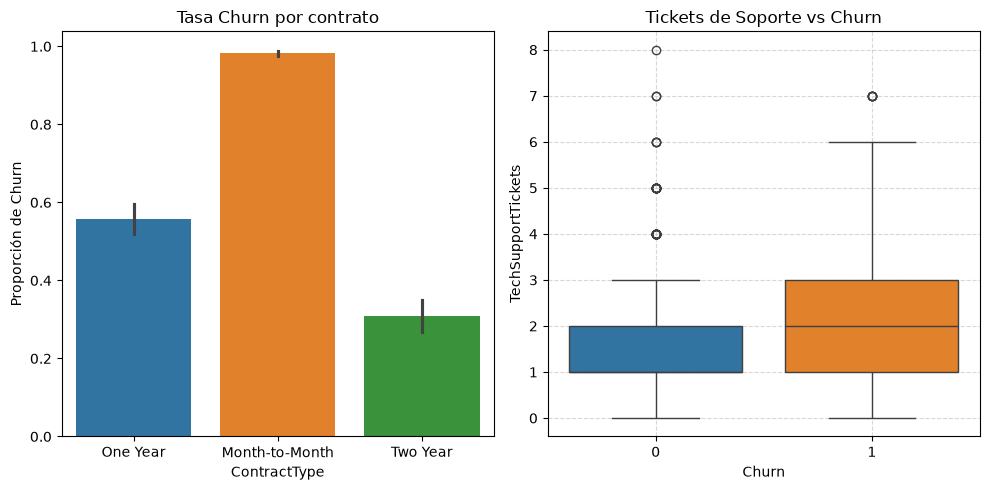

In [ ]:
""" Visualización de patrones de Negocio (EDA) """
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

# Churn por tipo de contrato
sns.barplot(data=df_raw, x="ContractType", y="Churn", hue="ContractType", ax=axes[0], legend=False) # errorbar=None (Si no deseas las Error Bars o Confidence Intervals)
axes[0].set_title("Tasa Churn por contrato")
axes[0].set_ylabel("Proporción de Churn")


# Churn según Tickets de Soporte Técnico
sns.boxplot(data=df_raw, x="Churn", y="TechSupportTickets", hue="Churn", ax=axes[1], legend=False)
axes[1].set_title("Tickets de Soporte vs Churn")

plt.grid(True, linestyle = "--", alpha=0.5)
plt.tight_layout()
plt.show()

In [25]:
""" Feature Engineering (Creación de variables de valor de negocio) """
df = df_raw.copy()
# A. Intensidad de reclamos por mes de antigüedad
df["TicketPerMonth"] = df["TechSupportTickets"] / df["TenureMonths"]

# B. Ratio de gasto: Tarifa mensual vs Gasto Promedio Histórico
df["AvgHistoricalMonthlySpend"] = df["TotalCharges"] / df["TenureMonths"]
df["ChargeRatio"] = df["MonthlyCharges"] / df["AvgHistoricalMonthlySpend"]

# C. Índice de Riesgo de Inactividad
df['InactivityRiskIndex'] = np.where(
    df["TechSupportTickets"].eq(0),
    df["DaysSinceLastLogin"] * 1,
    df["DaysSinceLastLogin"] * df["TechSupportTickets"]
)

df.head()

,CustomerID,TenureMonths,ContractType,PaymentMethod,MonthlyCharges,TotalCharges,TechSupportTickets,DaysSinceLastLogin,DiscountUsed,Churn,FutureLTV_12M,TicketPerMonth,AvgHistoricalMonthlySpend,ChargeRatio,InactivityRiskIndex
0,CUST-1000,52,One Year,Bank Transfer,76.16,3663.83,1,34,0,1,100.09,0.019231,70.458269,1.080924,34
1,CUST-1001,15,One Year,Bank Transfer,27.31,380.61,3,16,0,1,46.78,0.200000,25.374000,1.076299,48
2,CUST-1002,61,Month-to-Month,Credit Card,96.46,5641.10,3,11,1,1,136.88,0.049180,92.477049,1.043070,33
3,CUST-1003,21,Two Year,Bank Transfer,48.47,1062.93,2,35,1,1,71.28,0.095238,50.615714,0.957608,70
4,CUST-1004,24,Two Year,Electronic Check,108.76,2648.44,3,23,1,1,212.86,0.125000,110.351667,0.985576,69


In [32]:
df.to_csv(rf"C:\Users\Highlightning\Documents\Ciencia de Datos\Proyectos\Churn Predictor and LTV\data\processed\churn_feature_data.csv", index=False)
print(f"Dataset procesado con Feature Engineering guardado")

Dataset procesado con Feature Engineering guardado
